In [1]:
# # Create a local folder
# !mkdir -p /content/raw_marketing_data

# # Copy everything from the bucket to your notebook's hard drive
# !gcloud storage cp gs://marketing_channel_analysis/*.parquet /content/raw_marketing_data/

Copying gs://marketing_channel_analysis/members_v3.parquet to file:///content/raw_marketing_data/members_v3.parquet
Copying gs://marketing_channel_analysis/transactions.parquet to file:///content/raw_marketing_data/transactions.parquet
Copying gs://marketing_channel_analysis/transactions_v2.parquet to file:///content/raw_marketing_data/transactions_v2.parquet
Copying gs://marketing_channel_analysis/user_logs.parquet to file:///content/raw_marketing_data/user_logs.parquet
Copying gs://marketing_channel_analysis/user_logs_v2.parquet to file:///content/raw_marketing_data/user_logs_v2.parquet

Average throughput: 141.9MiB/s


In [2]:
import duckdb
import os

# Connect to the in-memory DuckDB engine
con = duckdb.connect()

# Set the path variable based on your folder structure
data_path = '/content/raw_marketing_data/'

print("Initiating Transaction Merge...")
# 1. Stack the Transactions and write to a new Parquet file
con.execute(f"""
    COPY (
        SELECT * FROM '{data_path}transactions.parquet'
        UNION ALL
        SELECT * FROM '{data_path}transactions_v2.parquet'
    ) TO '{data_path}master_transactions.parquet' (FORMAT PARQUET);
""")

print("Master Transactions built. Nuking raw transaction fragments...")
os.remove(f'{data_path}transactions.parquet')
os.remove(f'{data_path}transactions_v2.parquet')


print("Initiating User Logs Merge (This is heavy, standby)...")
# 2. Stack the massive User Logs and write to a new Parquet file
con.execute(f"""
    COPY (
        SELECT * FROM '{data_path}user_logs.parquet'
        UNION ALL
        SELECT * FROM '{data_path}user_logs_v2.parquet'
    ) TO '{data_path}master_user_logs.parquet' (FORMAT PARQUET);
""")

print("Master User Logs built. Nuking raw log fragments...")
os.remove(f'{data_path}user_logs.parquet')
os.remove(f'{data_path}user_logs_v2.parquet')

print("Consolidation Complete. Disk space recovered.")

Initiating Transaction Merge...


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Master Transactions built. Nuking raw transaction fragments...
Initiating User Logs Merge (This is heavy, standby)...


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Master User Logs built. Nuking raw log fragments...
Consolidation Complete. Disk space recovered.


# find business questions

# "Which registration channels are actually paying our bills?"


In [ ]:
path_memeber = '/content/raw_marketing_data/members_v3.parquet'
path_user_logs = '/content/raw_marketing_data/master_user_logs.parquet'
path_transactions = '/content/raw_marketing_data/master_transactions.parquet'

In [ ]:
import duckdb

con = duckdb.connect()

In [ ]:
# Enter user id here
user_id = 'JcyN8u3Ff029kyISUzntcV9T4o96evIg0HYBiPfXKnQ='

query = f"""
SELECT *
FROM read_parquet('{path_transactions}')
WHERE msno = '{user_id}'
ORDER BY transaction_date
"""

df = con.sql(query).df()

display(df)
print("Rows:", df.shape[0])

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,msno,payment_method_id,payment_plan_days,plan_list_price,actual_amount_paid,is_auto_renew,transaction_date,membership_expire_date,is_cancel
0,JcyN8u3Ff029kyISUzntcV9T4o96evIg0HYBiPfXKnQ=,30,30,149,0,1,20150826,20150925,0
1,JcyN8u3Ff029kyISUzntcV9T4o96evIg0HYBiPfXKnQ=,30,30,149,149,1,20150923,20150923,1


Rows: 2


In [ ]:
# Enter user id here
user_id = 'bwGIPjvFQ7wgqNxsAfjIN1vb45jb2oKQHSF3ih4jwsA='

query = f"""
SELECT *
FROM read_parquet('{path_transactions}')
WHERE msno = '{user_id}'
ORDER BY transaction_date
"""

df = con.sql(query).df()

display(df)
print("Rows:", df.shape[0])

,msno,payment_method_id,payment_plan_days,plan_list_price,actual_amount_paid,is_auto_renew,transaction_date,membership_expire_date,is_cancel
0,bwGIPjvFQ7wgqNxsAfjIN1vb45jb2oKQHSF3ih4jwsA=,38,30,149,149,0,20150826,20150925,0
1,bwGIPjvFQ7wgqNxsAfjIN1vb45jb2oKQHSF3ih4jwsA=,35,7,0,0,0,20150826,20151005,0
2,bwGIPjvFQ7wgqNxsAfjIN1vb45jb2oKQHSF3ih4jwsA=,35,7,0,0,0,20161029,20161105,0


Rows: 3


In [ ]:
# ==========================================================
# AGGREGATE TRANSACTIONS ONLY (TITANIUM VERSION)
# DuckDB + Parquet Optimized + Window Functions
# ==========================================================

import duckdb

con = duckdb.connect()

path_transactions = '/content/raw_marketing_data/master_transactions.parquet'

query = f"""
-- STEP 1: The "Time Machine" (Rank all transactions by date)
WITH transaction_ranked AS (
    SELECT
        msno,
        payment_method_id,
        is_auto_renew,
        is_cancel,
        transaction_date,
        -- Tie-breaker added: Agar date same ho toh aage ki expiry date uthao
        ROW_NUMBER() OVER(PARTITION BY msno ORDER BY transaction_date DESC, membership_expire_date DESC) as rn
    FROM read_parquet('{path_transactions}')
),

-- STEP 2: Extract ONLY the Latest Status (Where rn = 1)
transaction_latest AS (
    SELECT
        msno,
        payment_method_id AS latest_payment_method_id,
        is_auto_renew AS latest_is_auto_renew,
        is_cancel AS latest_is_cancel
    FROM transaction_ranked
    WHERE rn = 1
),

-- STEP 3: The "Math Engine" (Calculate Totals and Averages)
transaction_agg AS (
    SELECT
        msno,

        -- Row count
        COUNT(*) AS total_transactions,

        -- Sum metrics
        SUM(payment_plan_days)  AS sum_payment_plan_days,
        SUM(plan_list_price)    AS sum_plan_list_price,
        SUM(actual_amount_paid) AS sum_actual_amount_paid,

        -- Avg metrics
        AVG(payment_plan_days)  AS avg_payment_plan_days,
        AVG(plan_list_price)    AS avg_plan_list_price,
        AVG(actual_amount_paid) AS avg_actual_amount_paid,

        -- Dates
        MIN(transaction_date) AS first_transaction_date,
        MAX(transaction_date) AS last_transaction_date,
        MAX(membership_expire_date) AS latest_membership_expire_date

    FROM read_parquet('{path_transactions}')
    GROUP BY msno
)

-- STEP 4: Combine the Math with the Latest Status
SELECT
    a.*,
    l.latest_payment_method_id,
    l.latest_is_auto_renew,
    l.latest_is_cancel

FROM transaction_agg a
JOIN transaction_latest l
    ON a.msno = l.msno
"""


# === SAVE AS PARQUET (DuckDB Native - 10x Faster) ===

output_path = '/content/raw_marketing_data/final_dashboard_data.parquet'

# Query ke aage COPY command laga do
export_query = f"COPY ({query}) TO '{output_path}' (FORMAT PARQUET);"

# Execute karo (Ye Pandas dataframe nahi banayega, seedha file save karega)
con.execute(export_query)

print(f"🚀 Data directly blasted to Parquet file at: {output_path}")

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

🚀 Data directly blasted to Parquet file at: /content/raw_marketing_data/final_dashboard_data.parquet


# transation aggragation

In [ ]:
trans_agg_path = '/content/raw_marketing_data/final_dashboard_data.parquet'

In [ ]:
q = f"""
SELECT COUNT(*) AS total_rows
FROM '{trans_agg_path}'
"""
result = duckdb.query(q).df()
result


,total_rows
0,2426143


In [ ]:
q = f"""
SELECT *
FROM '{trans_agg_path}'
limit 5
"""
result = duckdb.query(q).df()
result


,msno,total_transactions,sum_payment_plan_days,sum_plan_list_price,sum_actual_amount_paid,avg_payment_plan_days,avg_plan_list_price,avg_actual_amount_paid,first_transaction_date,last_transaction_date,latest_membership_expire_date,latest_payment_method_id,latest_is_auto_renew,latest_is_cancel
0,uQxbyACsPOEkTIrv9jZgoGXelGBW81ZsSZKy9fhj5Z8=,17,543.0,2533.0,2682.0,31.941176,149.000000,157.764706,20150131,20170124,20170510,32,0,0
1,LSmqNJ2wYnJ3u3uaKraRZPiItNih+5wWtk8fWgtIdPs=,23,510.0,2533.0,3427.0,22.173913,110.130435,149.000000,20150331,20170331,20170504,23,1,0
2,FS3m3axuEzQU/FuOMo6JPJphztVsHpwFwwe85aMUfGg=,21,603.0,2980.0,3129.0,28.714286,141.904762,149.000000,20150131,20170331,20170516,39,1,0
3,Ityacc48f1VRMmg25MXiEX8CFI5F36dVE/w1ZrcHXUY=,21,603.0,2980.0,3129.0,28.714286,141.904762,149.000000,20150131,20170331,20170501,39,1,0
4,F/efiuVuZduaitXC9JzwqpvQWN5hv3oxGBX3mZU44Sk=,9,240.0,1192.0,1341.0,26.666667,132.444444,149.000000,20150131,20150918,20150930,41,1,1


In [ ]:
import pandas as pd

# 0. Data ko Hard Drive se wapas RAM (df) mein load karo
trans_agg_path = '/content/raw_marketing_data/final_dashboard_data.parquet'
df = pd.read_parquet(trans_agg_path)

# 1. Sabse pehle dekho ki paise ka distribution kaisa hai
print("--- Money Distribution ---")
print(df['sum_actual_amount_paid'].describe())

# 2. IRON MAN MOVE: Top 25% (75th Percentile) ka cutoff number nikalo
high_value_cutoff = df['sum_actual_amount_paid'].quantile(0.75)

print(f"\n🚀 The Magic Cut-off: ${high_value_cutoff}")
print(f"Jo user ${high_value_cutoff} se zyada de raha hai, wahi tumhara HIGH-VALUE user hai.")

--- Money Distribution ---
count    2.426143e+06
mean     1.426987e+03
std      1.420194e+03
min      0.000000e+00
25%      0.000000e+00
50%      1.032000e+03
75%      2.489000e+03
max      3.429900e+04
Name: sum_actual_amount_paid, dtype: float64

🚀 The Magic Cut-off: $2489.0
Jo user $2489.0 se zyada de raha hai, wahi tumhara HIGH-VALUE user hai.


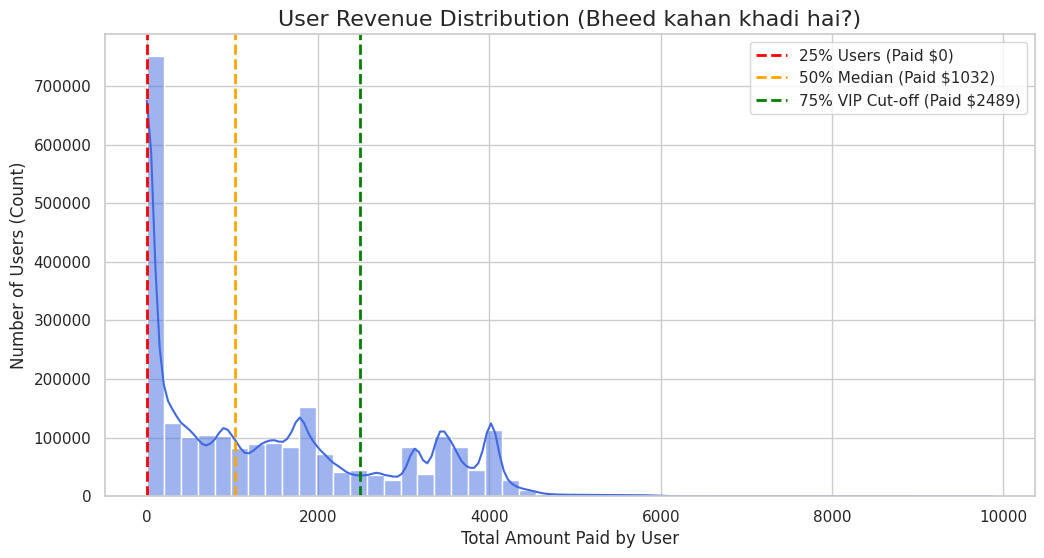

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Graph ka style aur size set karna
sns.set_theme(style="whitegrid")
plt.figure(figsize=(12, 6))

# The Senior Trick: Sirf 10,000 tak ka data plot kar rahe hain clarity ke liye
plot_data = df[df['sum_actual_amount_paid'] <= 10000]['sum_actual_amount_paid']

# Histogram plot karna
sns.histplot(plot_data, bins=50, kde=True, color='royalblue')

# Tumhare "Base" ko visual lines se mark karna
plt.axvline(x=0, color='red', linestyle='--', linewidth=2, label='25% Users (Paid $0)')
plt.axvline(x=1032, color='orange', linestyle='--', linewidth=2, label='50% Median (Paid $1032)')
plt.axvline(x=2489, color='green', linestyle='--', linewidth=2, label='75% VIP Cut-off (Paid $2489)')

plt.title('User Revenue Distribution (Bheed kahan khadi hai?)', fontsize=16)
plt.xlabel('Total Amount Paid by User', fontsize=12)
plt.ylabel('Number of Users (Count)', fontsize=12)
plt.legend()

# Graph show karo
plt.show()

In [ ]:
import pandas as pd
import numpy as np

# 1. Hum apne custom bins (buckets) define karenge based on tumhara graph
# Logic: -1 se 0, 0 se 500, 500 se 1032(Median), 1032 se 2489(VIP Cutoff), aage Whales
bins = [-1, 0, 500, 1032, 2489, 5000, float('inf')]

# 2. In buckets ko "Business Names" dete hain
labels = [
    '1. The Freeloaders ($0)',
    '2. Low Tier ($1 - $500)',
    '3. Below Average ($501 - $1032)',
    '4. Standard Tier ($1033 - $2489)',
    '5. The VIP Club ($2490 - $5000)',
    '6. The Whales ($5000+)'
]

# 3. Data ko buckets mein daalo
df['revenue_tier'] = pd.cut(df['sum_actual_amount_paid'], bins=bins, labels=labels)

# 4. Table banao (Group by and count)
distribution_table = df['revenue_tier'].value_counts().reset_index()
distribution_table.columns = ['Revenue Tier (Customer Type)', 'Exact User Count']

# 5. Senior Flex: Percentage nikalna
total_users = len(df)
distribution_table['% of Total Base'] = (distribution_table['Exact User Count'] / total_users * 100).round(2)

# Table ko order mein sort karo
distribution_table = distribution_table.sort_values(by='Revenue Tier (Customer Type)')

# 6. Result Print karo
print("--- 📊 ASLI BHEED KA POST-MORTEM (USER DISTRIBUTION TABLE) ---")
display(distribution_table) # Agar colab mein display kaam na kare, toh print(distribution_table) use karna

--- 📊 ASLI BHEED KA POST-MORTEM (USER DISTRIBUTION TABLE) ---


,Revenue Tier (Customer Type),Exact User Count,% of Total Base
0,1. The Freeloaders ($0),620152,25.56
3,2. Low Tier ($1 - $500),340224,14.02
4,3. Below Average ($501 - $1032),253168,10.43
1,4. Standard Tier ($1033 - $2489),606075,24.98
2,5. The VIP Club ($2490 - $5000),595290,24.54
5,6. The Whales ($5000+),11234,0.46


/tmp/ipykernel_153/1505387785.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


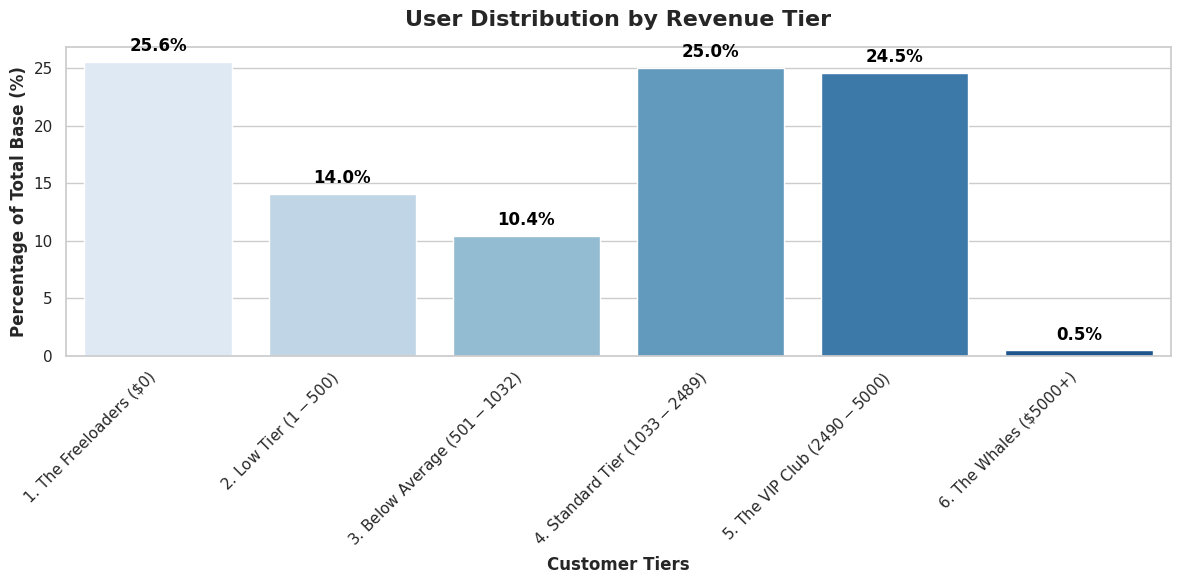

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Figure setup
plt.figure(figsize=(12, 6))
sns.set_theme(style="whitegrid")

# 2. Creating the vertical bar chart (matching your image)
# We will plot the Percentage on the Y-axis so the CFO sees the scale
ax = sns.barplot(
    data=distribution_table,
    x='Revenue Tier (Customer Type)',
    y='% of Total Base',
    palette='Blues' # Clean, professional single-color gradient
)

# 3. Adding the exact percentage numbers on top of each bar
for p in ax.patches:
    ax.annotate(f'{p.get_height():.1f}%',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom',
                fontweight='bold', color='black', xytext=(0, 5), textcoords='offset points')

# 4. Chart Formatting
plt.title('User Distribution by Revenue Tier', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Customer Tiers', fontsize=12, fontweight='bold')
plt.ylabel('Percentage of Total Base (%)', fontsize=12, fontweight='bold')

# Rotate the tier names at the bottom so they don't crash into each other
plt.xticks(rotation=45, ha='right')

# Display the chart
plt.tight_layout()
plt.show()

/tmp/ipykernel_153/442802724.py:45: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


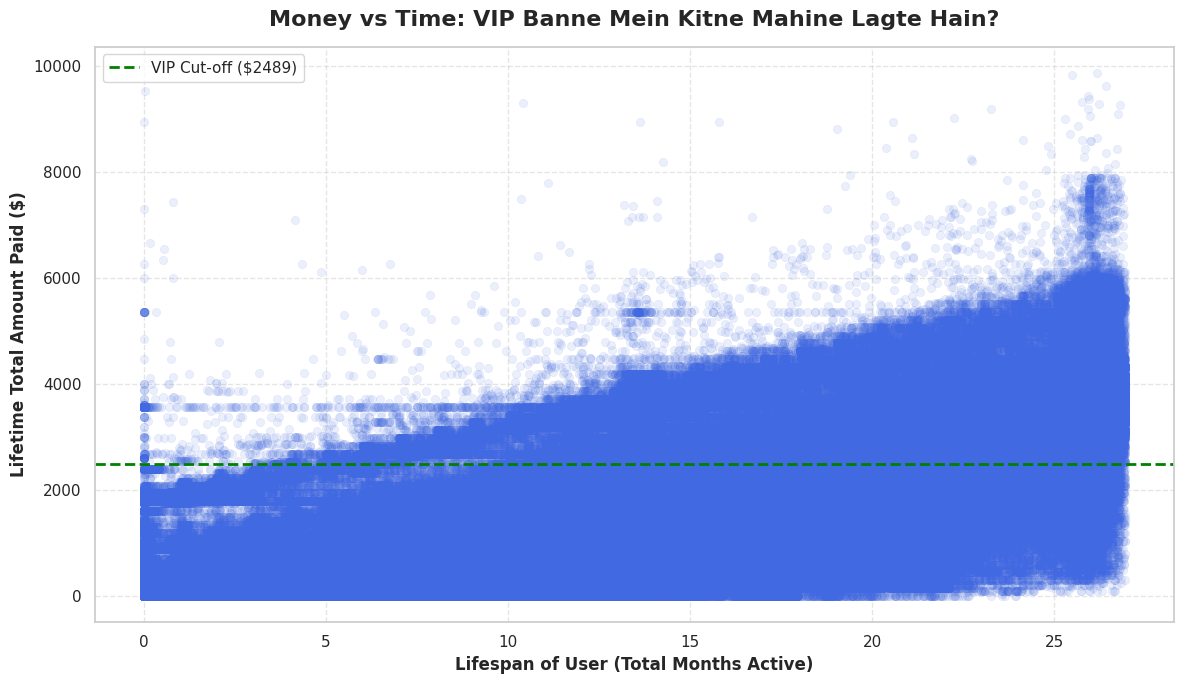

🚀 BRUTAL FACT: Tumhara ek average VIP user 22.7 months (lagbhag 1.9 saal) app par rukta hai!


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Dates ko sahi format (Datetime) mein convert karna
# Note: Kaggle/KKBox data mein dates aksar '20170131' (Integer/String) format mein hoti hain
df['first_date'] = pd.to_datetime(df['first_transaction_date'].astype(str), format='%Y%m%d', errors='coerce')
df['last_date'] = pd.to_datetime(df['last_transaction_date'].astype(str), format='%Y%m%d', errors='coerce')

# Agar dates already datetime format mein hain toh ye fallback use hoga:
if df['first_date'].isnull().all():
    df['first_date'] = pd.to_datetime(df['first_transaction_date'])
    df['last_date'] = pd.to_datetime(df['last_transaction_date'])

# 2. Waqt (Tenure) Calculate karna: Aakhiri payment aur pehli payment mein kitne din ka gap hai?
df['Tenure_Days'] = (df['last_date'] - df['first_date']).dt.days

# Tenure ko Months mein convert kar lo (samajhne mein aasan hoga)
df['Tenure_Months'] = df['Tenure_Days'] / 30.44

# 3. Graph banane ke liye data ready karna (Outliers hatakar taki graph clean dikhe)
plot_data = df[(df['sum_actual_amount_paid'] <= 10000) & (df['Tenure_Months'] >= 0)]

# 4. The Scatter Plot (Paisa vs Waqt)
plt.figure(figsize=(12, 7))
sns.scatterplot(
    data=plot_data,
    x='Tenure_Months',
    y='sum_actual_amount_paid',
    alpha=0.1,  # 0.1 transparency taki jahan bheed ho wahan dark color dikhe
    color='royalblue',
    edgecolor=None
)

# 5. Apna Magic Cut-off ($2489) Line lagana
plt.axhline(y=2489, color='green', linestyle='--', linewidth=2, label='VIP Cut-off ($2489)')

# Chart Formatting
plt.title('Money vs Time: VIP Banne Mein Kitne Mahine Lagte Hain?', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Lifespan of User (Total Months Active)', fontsize=12, fontweight='bold')
plt.ylabel('Lifetime Total Amount Paid ($)', fontsize=12, fontweight='bold')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

# 6. Senior Flex: VIPs ki average life batao
vip_life = df[df['sum_actual_amount_paid'] >= 2489]['Tenure_Months'].mean()
print(f"🚀 BRUTAL FACT: Tumhara ek average VIP user {vip_life:.1f} months (lagbhag {vip_life/12:.1f} saal) app par rukta hai!")

--- ⏳ TIMELINE SUMMARY ---
🚀 Data Starts From: 2015-01
🏁 Data Ends At:   2017-03
📅 Total Months:     27 Months (2.2 Years)
------------------------------


,Month-Year,Users Joined
0,2015-01,549166
1,2015-02,51155
2,2015-03,120105
3,2015-04,48968
4,2015-05,44929


,Month-Year,Users Joined
22,2016-11,145477
23,2016-12,41886
24,2017-01,38322
25,2017-02,37056
26,2017-03,34468


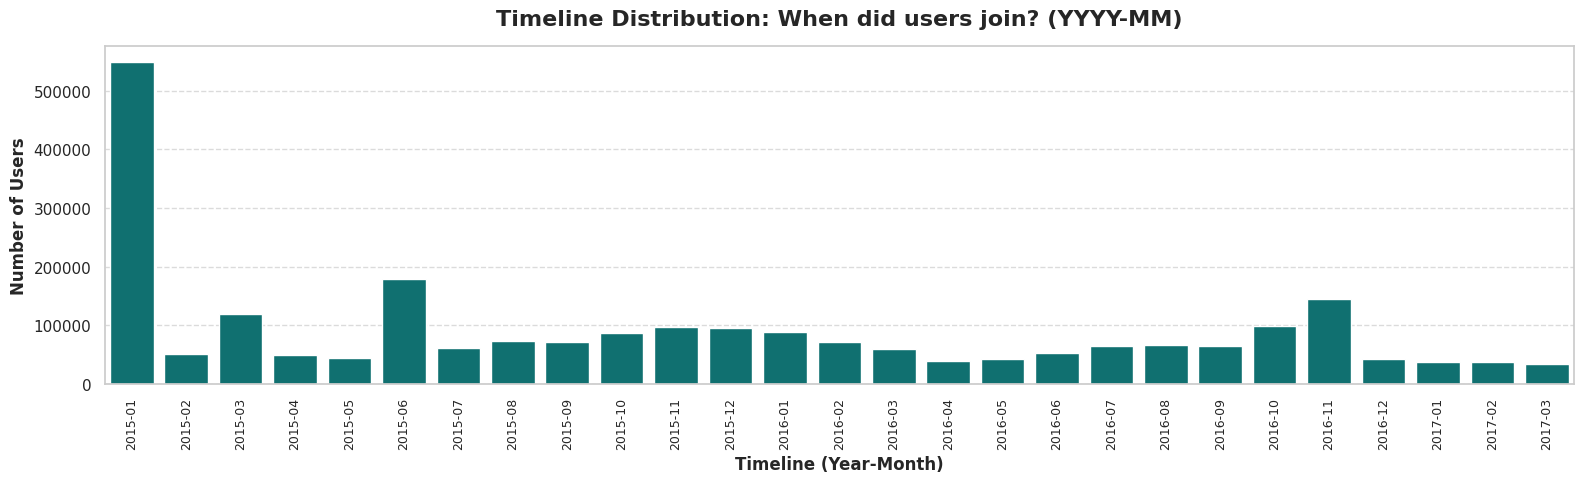

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Ensure the date column is in Datetime format
# (Handling the integer '20170131' format common in KKBox data)
df['first_date'] = pd.to_datetime(df['first_transaction_date'].astype(str), format='%Y%m%d', errors='coerce')

# Fallback in case it was already datetime
if df['first_date'].isnull().all():
    df['first_date'] = pd.to_datetime(df['first_transaction_date'])

# 2. Extract Month-Year (YYYY-MM Format)
# Ye saari dates (e.g., 2016-05-15) ko '2016-05' bana dega
df['Month_Year'] = df['first_date'].dt.strftime('%Y-%m')

# 3. Group By Month-Year (Count how many users started in each month)
timeline_dist = df.groupby('Month_Year')['msno'].count().reset_index()
timeline_dist.columns = ['Month-Year', 'Users Joined']

# 4. Sort chronologically (Purana time pehle, naya baad mein)
timeline_dist = timeline_dist.sort_values(by='Month-Year')

# 5. THE BRUTAL FACTS (CFO Summary)
print("--- ⏳ TIMELINE SUMMARY ---")
print(f"🚀 Data Starts From: {timeline_dist['Month-Year'].min()}")
print(f"🏁 Data Ends At:   {timeline_dist['Month-Year'].max()}")
print(f"📅 Total Months:     {len(timeline_dist)} Months ({len(timeline_dist)/12:.1f} Years)")
print("-" * 30)

# Print top 5 and bottom 5 rows to see the ends of the data
display(timeline_dist.head())
display(timeline_dist.tail())

# 6. The Visual Proof (Timeline Chart)
plt.figure(figsize=(16, 5))
sns.barplot(data=timeline_dist, x='Month-Year', y='Users Joined', color='teal')

plt.title('Timeline Distribution: When did users join? (YYYY-MM)', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Timeline (Year-Month)', fontsize=12, fontweight='bold')
plt.ylabel('Number of Users', fontsize=12, fontweight='bold')

# Rotate X-axis labels to 90 degrees so they don't crash into each other
plt.xticks(rotation=90, fontsize=9)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd

# Pandas ko force karo ki wo ek bhi row na chupaye
pd.set_option('display.max_rows', None)

# Pura data display karo (Sirf Month, Naye Aaye Log, aur Total Log)
print("--- 📅 FULL 27-MONTH USER DISTRIBUTION (2015-01 to 2017-03) ---")
display(timeline_dist[['Month-Year', 'Users Joined', 'Total_Accumulated_Users']])

# Wapas normal setting kar do taaki aage ke tables hang na karein
pd.reset_option('display.max_rows')

--- 📅 FULL 27-MONTH USER DISTRIBUTION (2015-01 to 2017-03) ---


,Month-Year,Users Joined,Total_Accumulated_Users
0,2015-01,549166,549166
1,2015-02,51155,600321
2,2015-03,120105,720426
3,2015-04,48968,769394
4,2015-05,44929,814323
5,2015-06,178429,992752
6,2015-07,60932,1053684
7,2015-08,72746,1126430
8,2015-09,71917,1198347
9,2015-10,86575,1284922


# loyalty condition

/tmp/ipykernel_153/3518815301.py:44: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
/tmp/ipykernel_153/3518815301.py:44: FutureWarning: 

The `scale` parameter has been renamed and will be removed in v0.15.0. Pass `density_norm='width'` for the same effect.
  sns.violinplot(


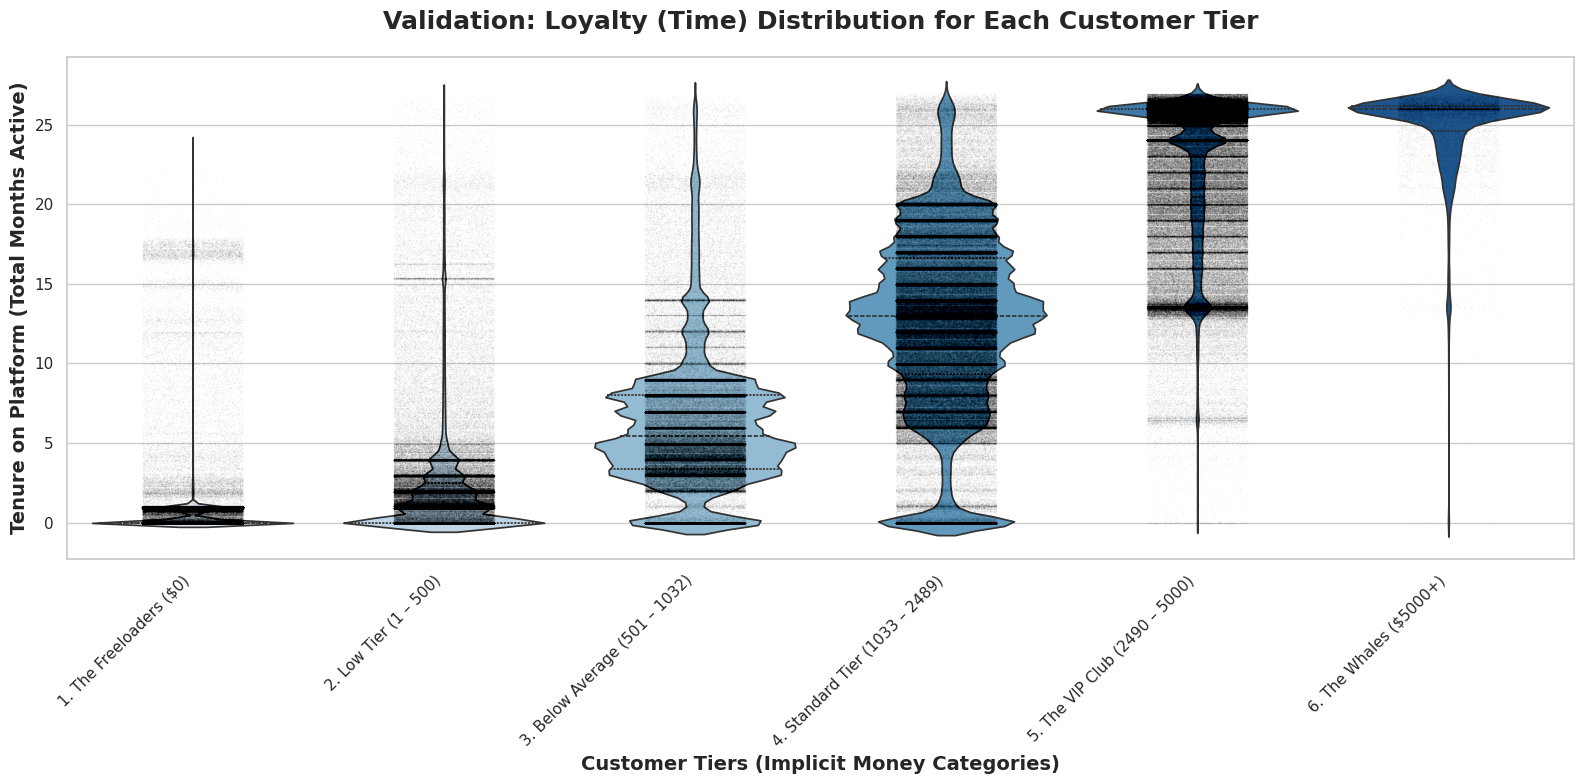


--- 🕵️‍♂️ PROOF: Tenure Analysis of 'The VIP Club' ---
These are the facts for the specific tier you want to analyze:


,Tenure_Months
count,595290.000000
mean,22.704281
std,4.612733
min,0.000000
25%,20.466491
50%,25.065703
75%,25.952694
max,26.938239


In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# --- STEP 1: DATE CONVERSION (CRITICAL) ---
# Ensure dates are datetime objects and handle common integer string format
df['first_date'] = pd.to_datetime(df['first_transaction_date'].astype(str), format='%Y%m%d', errors='coerce')
df['last_date'] = pd.to_datetime(df['last_transaction_date'].astype(str), format='%Y%m%d', errors='coerce')

# --- STEP 2: TENURE CALCULATION (VALIDATED) ---
# Days difference between first and last payment
df['Tenure_Days'] = (df['last_date'] - df['first_date']).dt.days

# Convert to Months (approximated, safe for large analysis)
df['Tenure_Months'] = df['Tenure_Days'] / 30.44

# Handle potential missing dates by setting them to -1 (avoid error, clean later)
df['Tenure_Months'] = df['Tenure_Months'].fillna(-1)

# Only keep users with valid, positive Tenure and Tenure <= 4 Years (to keep graph tidy)
clean_df = df[(df['Tenure_Months'] >= 0) & (df['Tenure_Months'] <= 48)].copy()

# --- STEP 3: CREATING THE REVENUE TIERS (FROM IMAGE_6.PNG) ---
# Define thresholds and names strictly from image_6.png and previous context
revenue_bins = [-1, 0, 500, 1032, 2489, 5000, float('inf')]
revenue_labels = [
    '1. The Freeloaders ($0)',
    '2. Low Tier (1 – 500)',
    '3. Below Average (501 – 1032)',
    '4. Standard Tier (1033 – 2489)',
    '5. The VIP Club (2490 – 5000)',
    '6. The Whales ($5000+)'
]

clean_df['Revenue Tier'] = pd.cut(clean_df['sum_actual_amount_paid'], bins=revenue_bins, labels=revenue_labels)

# --- STEP 4: VIOLIN PLOT (TIER VS TIME) ---
# Set theme and size
sns.set_theme(style="whitegrid")
plt.figure(figsize=(16, 8))

# Interactive Violin: Show distribution (bheed kahan hai?)
sns.violinplot(
    data=clean_df,
    x='Revenue Tier',
    y='Tenure_Months',
    palette='Blues',
    scale='width', # Each violin has equal total width (normalized)
    inner='quartile' # Show internal quartile lines
)

# Scatter Overlay: Show exact data points as jitter
# Transparency low (alpha) to avoid clutter, set tiny points
sns.stripplot(
    data=clean_df,
    x='Revenue Tier',
    y='Tenure_Months',
    color='black',
    alpha=0.03, # Very faint, so clutter is not overwhelming
    jitter=0.2, # Adds random horizontal shift to separate points
    size=1 # Tiny points
)

# Chart Formatting
plt.title('Validation: Loyalty (Time) Distribution for Each Customer Tier', fontsize=18, fontweight='bold', pad=20)
plt.ylabel('Tenure on Platform (Total Months Active)', fontsize=14, fontweight='bold')
plt.xlabel('Customer Tiers (Implicit Money Categories)', fontsize=14, fontweight='bold')

# Rotate labels 45 degrees so they don't crash
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()

# --- STEP 5: PROOF IN NUMBERS (SENIOR FLEX) ---
# Get exact median, min, max tenure for the main problem tier 'The VIP Club'
vip_tenure_data = clean_df[clean_df['Revenue Tier'] == '5. The VIP Club (2490 – 5000)']['Tenure_Months'].describe()

print("\n--- 🕵️‍♂️ PROOF: Tenure Analysis of 'The VIP Club' ---")
print("These are the facts for the specific tier you want to analyze:")
display(vip_tenure_data)

In [ ]:
import pandas as pd
import numpy as np

# 1. DATES KO SAHI FORMAT MEIN LANA
df['first_date'] = pd.to_datetime(df['first_transaction_date'].astype(str), format='%Y%m%d', errors='coerce')
df['last_date'] = pd.to_datetime(df['last_transaction_date'].astype(str), format='%Y%m%d', errors='coerce')

# 2. EXACT MONTHS CALCULATE KARNA (The Iron Man Way)
df['Tenure_Days'] = (df['last_date'] - df['first_date']).dt.days
df['Tenure_Months'] = df['Tenure_Days'] / 30.44

# Safety Check: Agar koi negative value aayi ho, usko 0 kar do
df['Tenure_Months'] = df['Tenure_Months'].clip(lower=0)

# 3. BHEED KO UNKE TIERS MEIN BANTO
revenue_bins = [-1, 0, 500, 1032, 2489, 5000, float('inf')]
revenue_labels = [
    '1. The Freeloaders ($0)',
    '2. Low Tier (1 - 500)',
    '3. Below Average (501 - 1032)',
    '4. Standard Tier (1033 - 2489)',
    '5. The VIP Club (2490 - 5000)',
    '6. The Whales ($5000+)'
]
df['Revenue Tier'] = pd.cut(df['sum_actual_amount_paid'], bins=revenue_bins, labels=revenue_labels)

# 4. THE MASTER TABLE (Group By Tier)
tenure_table = df.groupby('Revenue Tier', observed=False)['Tenure_Months'].agg(
    Exact_User_Count='count',
    Average_Months='mean',
    Median_Months='median',
    Max_Months_Seen='max'
).reset_index()

# === 🚀 THE NEW UPDATE: PERCENTAGE COLUMN ===
# Pehle sabhi tiers ke users ko jod kar 'Total Users' nikalo
total_users = tenure_table['Exact_User_Count'].sum()

# Ab har tier ka percentage nikalo (Exact Count / Total Users * 100)
tenure_table['Percentage_User_Count (%)'] = (tenure_table['Exact_User_Count'] / total_users * 100).round(2)

# Table padhne mein aasan ho, isliye Columns ko reorder kar dete hain
columns_order = [
    'Revenue Tier',
    'Exact_User_Count',
    'Percentage_User_Count (%)', # Naya column exactly Count ke baad
    'Average_Months',
    'Median_Months',
    'Max_Months_Seen'
]
tenure_table = tenure_table[columns_order]

# Months ko round off kar do
tenure_table['Average_Months'] = tenure_table['Average_Months'].round(1)
tenure_table['Median_Months'] = tenure_table['Median_Months'].round(1)
tenure_table['Max_Months_Seen'] = tenure_table['Max_Months_Seen'].round(1)

# 5. PRINT THE RESULT
print("--- ⏱️ EXACT TIME SPENT BY EACH TIER (WITH PERCENTAGES) ---")
display(tenure_table)

--- ⏱️ EXACT TIME SPENT BY EACH TIER (WITH PERCENTAGES) ---


,Revenue Tier,Exact_User_Count,Percentage_User_Count (%),Average_Months,Median_Months,Max_Months_Seen
0,1. The Freeloaders ($0),620152,25.56,0.6,0.0,23.9
1,2. Low Tier (1 - 500),340224,14.02,2.1,1.0,26.9
2,3. Below Average (501 - 1032),253168,10.43,6.2,5.4,26.9
3,4. Standard Tier (1033 - 2489),606075,24.98,12.6,12.9,26.9
4,5. The VIP Club (2490 - 5000),595290,24.54,22.7,25.1,26.9
5,6. The Whales ($5000+),11234,0.46,24.8,26.0,26.9


# join mebers and transaction

In [ ]:
path_memebr ='/content/raw_marketing_data/members_v3.parquet'

In [ ]:
q = f"""
SELECT *
FROM '{path_memebr}'
limit 5
"""
result = duckdb.query(q).df()
result


,msno,city,bd,gender,registered_via,registration_init_time
0,Rb9UwLQTrxzBVwCB6+bCcSQWZ9JiNLC9dXtM1oEsZA8=,1,0,None,11,20110911
1,+tJonkh+O1CA796Fm5X60UMOtB6POHAwPjbTRVl/EuU=,1,0,None,7,20110914
2,cV358ssn7a0f7jZOwGNWS07wCKVqxyiImJUX6xcIwKw=,1,0,None,11,20110915
3,9bzDeJP6sQodK73K5CBlJ6fgIQzPeLnRl0p5B77XP+g=,1,0,None,11,20110915
4,WFLY3s7z4EZsieHCt63XrsdtfTEmJ+2PnnKLH5GY4Tk=,6,32,female,9,20110915


In [ ]:
import pandas as pd
import gc # Garbage collector memory clean karne ke liye

print("Initiating System Upgrade: Updating final_dashboard_data.parquet...")

# Paths set karo (Image ke hisaab se)
target_path = 'raw_marketing_data/final_dashboard_data.parquet'
members_path = 'raw_marketing_data/members_v3.parquet'

# STEP 1: Load Dashboard Data (Tumhara 2.4M paying users wala base)
dashboard_df = pd.read_parquet(target_path)
print(f"Base data loaded. Current rows: {len(dashboard_df):,}")

# STEP 2: Load ONLY REQUIRED columns from Members Data (Saves MASSIVE RAM)
# Sirf msno aur wo 2 columns jo tumhe chahiye
columns_to_fetch = ['msno', 'registered_via', 'registration_init_time']
members_df = pd.read_parquet(members_path, columns=columns_to_fetch)
print("Member columns fetched successfully.")

# STEP 3: The Left Join (Dashboard data par naye columns chipkana)
# Hum dashboard_df ko hi update kar rahe hain, naya variable nahi bana rahe
dashboard_df = dashboard_df.merge(members_df, on='msno', how='left')
print(f"Merge complete. New columns added. Checking rows: {len(dashboard_df):,} (Should be exactly same as Base data!)")

# RAM free karo (Senior Engineer move)
del members_df
gc.collect()

# STEP 4: OVERWRITE THE FILE (The Iron Man Command)
# Ye existing file ko delete karke nayi updated file save kar dega
dashboard_df.to_parquet(target_path, index=False)
print("✅ SUCCESS: final_dashboard_data.parquet has been overwritten with new columns!")

# STEP 5: Verification (Proof)
display(dashboard_df[['msno', 'sum_actual_amount_paid', 'registered_via', 'registration_init_time']].head())

Initiating System Upgrade: Updating final_dashboard_data.parquet...
Base data loaded. Current rows: 2,426,143
Member columns fetched successfully.
Merge complete. New columns added. Checking rows: 2,426,143 (Should be exactly same as Base data!)
✅ SUCCESS: final_dashboard_data.parquet has been overwritten with new columns!


,msno,sum_actual_amount_paid,registered_via,registration_init_time
0,zvdOYkuJw+l9dy6tAoWIfue3hFArtoP2b29rp6hmi+c=,3963.0,7.0,20120307.0
1,gV8BXr55HzHNe2/k4rYryZcKIJDf/Qy8nuwgiSPp6ts=,4023.0,7.0,20110524.0
2,qeKaMUxxI6mkREkv4TjfSlhuRguXcHLgCU85qdjuV6Y=,3834.0,9.0,20070618.0
3,pfJ0tXXzX/hw+8u/1UQw6MZ8m/iS/0HTu8I6aj93xdU=,4271.0,3.0,20130130.0
4,LjY17soH840CUVDpEUci4WgdD58E+ZiGbPz0uX75kns=,4121.0,7.0,20140714.0


# add tenue column in final dashbord data

In [ ]:
import pandas as pd
import gc

print("Initiating System Patch: Calculating Tenure_Days...")

# Path set karo
target_path = 'raw_marketing_data/final_dashboard_data.parquet'

# STEP 1: Load the Base Data
dashboard_df = pd.read_parquet(target_path)
print(f"Data loaded successfully. Processing {len(dashboard_df):,} rows...")

# STEP 2: The Time Machine (Converting Integer to Date)
# Memory bachane ke liye hum naye columns nahi bana rahe, temporary variables (Series) use kar rahe hain
first_date = pd.to_datetime(dashboard_df['first_transaction_date'].astype(str), format='%Y%m%d', errors='coerce')
last_date = pd.to_datetime(dashboard_df['last_transaction_date'].astype(str), format='%Y%m%d', errors='coerce')

# STEP 3: Calculate Exact Tenure in Days
dashboard_df['Tenure_Days'] = (last_date - first_date).dt.days

# Safety Check: Agar data mein koi error ho jiski wajah se negative din aayen, ya NaN ho, use 0 kar do
dashboard_df['Tenure_Days'] = dashboard_df['Tenure_Days'].fillna(0).clip(lower=0)
print("Tenure_Days calculated safely.")

# STEP 4: OVERWRITE THE FILE (The Iron Man Command)
dashboard_df.to_parquet(target_path, index=False)
print("✅ SUCCESS: Tenure_Days added and final_dashboard_data.parquet has been overwritten!")

# Memory clean up
del first_date
del last_date
gc.collect()

# STEP 5: Verification
print("\n--- ⏱️ TENURE VERIFICATION ---")
display(dashboard_df[['msno', 'first_transaction_date', 'last_transaction_date', 'Tenure_Days']].head())

Initiating System Patch: Calculating Tenure_Days...
Data loaded successfully. Processing 2,426,143 rows...
Tenure_Days calculated safely.
✅ SUCCESS: Tenure_Days added and final_dashboard_data.parquet has been overwritten!

--- ⏱️ TENURE VERIFICATION ---


,msno,first_transaction_date,last_transaction_date,Tenure_Days
0,zvdOYkuJw+l9dy6tAoWIfue3hFArtoP2b29rp6hmi+c=,20150120,20170320,790
1,gV8BXr55HzHNe2/k4rYryZcKIJDf/Qy8nuwgiSPp6ts=,20150125,20170325,790
2,qeKaMUxxI6mkREkv4TjfSlhuRguXcHLgCU85qdjuV6Y=,20150103,20161226,723
3,pfJ0tXXzX/hw+8u/1UQw6MZ8m/iS/0HTu8I6aj93xdU=,20150127,20170304,767
4,LjY17soH840CUVDpEUci4WgdD58E+ZiGbPz0uX75kns=,20150113,20170331,808


In [ ]:
q = f"""
SELECT *
FROM '{trans_agg_path}'
limit 5
"""
result = duckdb.query(q).df()
result


,msno,total_transactions,sum_payment_plan_days,sum_plan_list_price,sum_actual_amount_paid,avg_payment_plan_days,avg_plan_list_price,avg_actual_amount_paid,first_transaction_date,last_transaction_date,latest_membership_expire_date,latest_payment_method_id,latest_is_auto_renew,latest_is_cancel,registered_via,registration_init_time,Tenure_Days
0,zvdOYkuJw+l9dy6tAoWIfue3hFArtoP2b29rp6hmi+c=,27,810.0,4023.0,3963.0,30.000000,149.000000,146.777778,20150120,20170320,20170421,41,1,0,7.0,20120307.0,790
1,gV8BXr55HzHNe2/k4rYryZcKIJDf/Qy8nuwgiSPp6ts=,27,780.0,3874.0,4023.0,28.888889,143.481481,149.000000,20150125,20170325,20170426,41,1,0,7.0,20110524.0,790
2,qeKaMUxxI6mkREkv4TjfSlhuRguXcHLgCU85qdjuV6Y=,24,694.0,3685.0,3834.0,28.916667,153.541667,159.750000,20150103,20161226,20170125,36,0,0,9.0,20070618.0,723
3,pfJ0tXXzX/hw+8u/1UQw6MZ8m/iS/0HTu8I6aj93xdU=,27,783.0,4122.0,4271.0,29.000000,152.666667,158.185185,20150127,20170304,20170403,36,1,0,3.0,20130130.0,767
4,LjY17soH840CUVDpEUci4WgdD58E+ZiGbPz0uX75kns=,29,840.0,3972.0,4121.0,28.965517,136.965517,142.103448,20150113,20170331,20170430,41,1,0,7.0,20140714.0,808


# Answer of this question which registartion chaneel pating our bills

# create is_high_value_user

In [ ]:
# ==========================================
# SCRIPT 1: DATA ENGINEERING (ETL)
# Goal: Add VIP Flag and Save File
# ==========================================
import pandas as pd
import gc

print("⚙️ Initiating Data Pipeline: Adding 'is_High_Value_User' flag...")

# 1. LOAD THE DATA
target_path = 'raw_marketing_data/final_dashboard_data.parquet'
dashboard_df = pd.read_parquet(target_path)

# 2. THE 3 BRUTAL CONDITIONS (VIP DEFINITION)
cond_money = dashboard_df['sum_actual_amount_paid'] >= 2489
cond_margin = dashboard_df['sum_actual_amount_paid'] >= dashboard_df['sum_plan_list_price']
cond_loyalty = dashboard_df['Tenure_Days'] >= 365

# 3. CREATE THE 1/0 COLUMN
dashboard_df['is_High_Value_User'] = (cond_money & cond_margin & cond_loyalty).astype(int)

# 4. OVERWRITE PARQUET FILE (Permanent Save)
dashboard_df.to_parquet(target_path, index=False)

print("✅ SUCCESS: File updated! 'is_High_Value_User' (1/0) permanently saved to final_dashboard_data.parquet.")

# Memory cleanup
del dashboard_df
gc.collect()

⚙️ Initiating Data Pipeline: Adding 'is_High_Value_User' flag...
✅ SUCCESS: File updated! 'is_High_Value_User' (1/0) permanently saved to final_dashboard_data.parquet.


0

In [ ]:
# ==========================================
# SCRIPT 2: THE CFO REPORTING ENGINE
# Goal: Analyze Which Channel Pays the Bills
# ==========================================
import pandas as pd

print("📊 Generating Channel ROI Report...\n")

# 1. LOAD THE UPDATED DATA (Sirf zaroori columns load kar rahe hain memory bachane ke liye)
target_path = 'raw_marketing_data/final_dashboard_data.parquet'
columns_needed = ['msno', 'registered_via', 'is_High_Value_User', 'sum_actual_amount_paid']
df_report = pd.read_parquet(target_path, columns=columns_needed)

# 2. THE CHANNEL MASTER TABLE
channel_roi = df_report.groupby('registered_via', observed=False).agg(
    Total_Users=('msno', 'count'),
    Total_VIPs=('is_High_Value_User', 'sum'), # 1 aur 0 ko sum karega
    Total_Revenue=('sum_actual_amount_paid', 'sum')
).reset_index()

# 3. CALCULATING THE METRICS
# VIP Conversion Rate (Kitne % log VIP bane)
channel_roi['VIP_Conversion_Rate (%)'] = ((channel_roi['Total_VIPs'] / channel_roi['Total_Users']) * 100).round(2)

# Average Revenue Per User (ANRPU) for that channel
channel_roi['Avg_Revenue_Per_User ($)'] = (channel_roi['Total_Revenue'] / channel_roi['Total_Users']).round(2)

# 4. SORTING (Top Bill Payers First)
channel_roi = channel_roi.sort_values(by='Total_Revenue', ascending=False)

# 5. DISPLAY THE RESULTS
print("--- 🏆 WHICH CHANNEL IS PAYING OUR BILLS? ---")
display(channel_roi.head(20))

📊 Generating Channel ROI Report...

--- 🏆 WHICH CHANNEL IS PAYING OUR BILLS? ---


,registered_via,Total_Users,Total_VIPs,Total_Revenue,VIP_Conversion_Rate (%),Avg_Revenue_Per_User ($)
2,7.0,678287,166990,1.258697e+09,24.62,1855.70
3,9.0,634577,255602,1.250328e+09,40.28,1970.33
0,3.0,401095,94748,5.348579e+08,23.62,1333.49
1,4.0,269454,4604,1.301211e+08,1.71,482.91
5,13.0,4910,0,2.135657e+06,0.00,434.96
4,10.0,9,0,2.086000e+03,0.00,231.78
6,16.0,1,0,0.000000e+00,0.00,0.00


--- 📊 TOTAL CHANNELS FOUND: 7 ---


,registered_via,User_Count,Percentage (%)
2,7.0,678287,34.11
3,9.0,634577,31.92
0,3.0,401095,20.17
1,4.0,269454,13.55
5,13.0,4910,0.25
4,10.0,9,0.00
6,16.0,1,0.00


/tmp/ipykernel_232/237125537.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=channel_dist, x='registered_via', y='User_Count', palette='viridis')


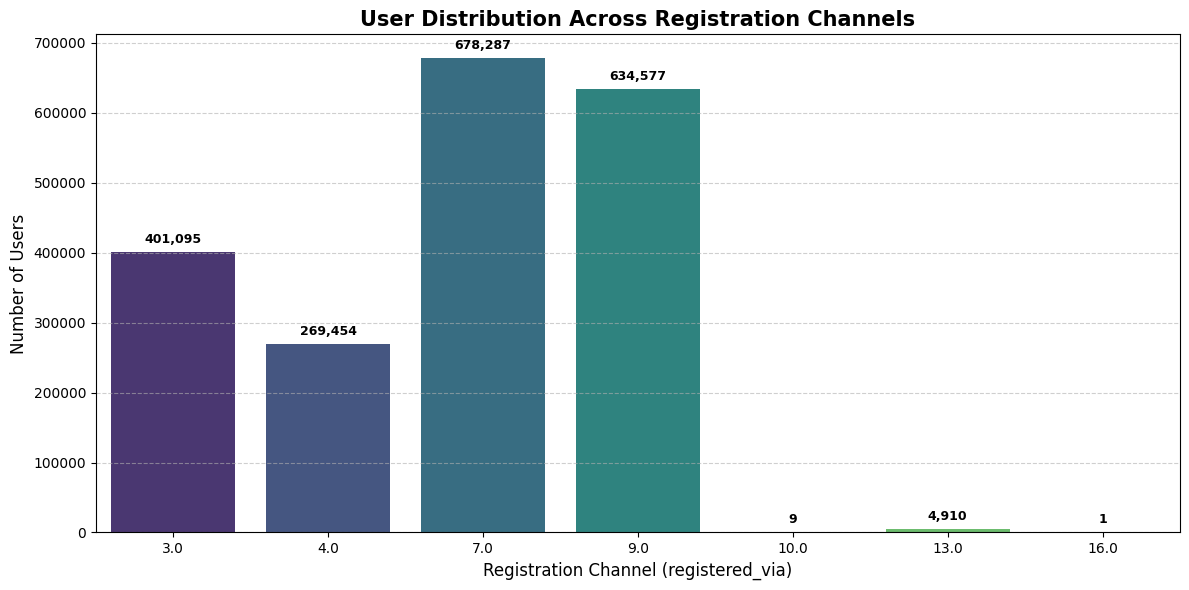

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. LOAD DATA (Sirf zaroori columns)
target_path = 'raw_marketing_data/final_dashboard_data.parquet'
df_channels = pd.read_parquet(target_path, columns=['msno', 'registered_via'])

# 2. CALCULATE DISTRIBUTION
channel_dist = df_channels.groupby('registered_via').agg(
    User_Count=('msno', 'count')
).reset_index()

# Sort by count (Sabse bada channel upar)
channel_dist = channel_dist.sort_values(by='User_Count', ascending=False)

# Percentage calculation
total_users = channel_dist['User_Count'].sum()
channel_dist['Percentage (%)'] = ((channel_dist['User_Count'] / total_users) * 100).round(2)

# 3. DISPLAY TABLE
print(f"--- 📊 TOTAL CHANNELS FOUND: {len(channel_dist)} ---")
display(channel_dist)

# 4. VISUALIZE (The Volume Bar Chart)
plt.figure(figsize=(12, 6))
ax = sns.barplot(data=channel_dist, x='registered_via', y='User_Count', palette='viridis')

# Bars ke upar numbers likhna
for p in ax.patches:
    ax.annotate(f'{int(p.get_height()):,}',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha = 'center', va = 'center',
                xytext = (0, 9),
                textcoords = 'offset points',
                fontsize=9, fontweight='bold')

plt.title('User Distribution Across Registration Channels', fontsize=15, fontweight='bold')
plt.xlabel('Registration Channel (registered_via)', fontsize=12)
plt.ylabel('Number of Users', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

In [ ]:
# Check for null values in registered_via
missing_count = df_channels['registered_via'].isnull().sum()
print(f"Missing (Null) Users: {missing_count:,}")

Missing (Null) Users: 437,810


/tmp/ipykernel_232/3037515768.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=channel_dist, x='registered_via', y='User_Count', palette='magma')
/tmp/ipykernel_232/3037515768.py:44: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  plt.gca().set_yticklabels(['{:,.0f}'.format(x) for x in current_values])


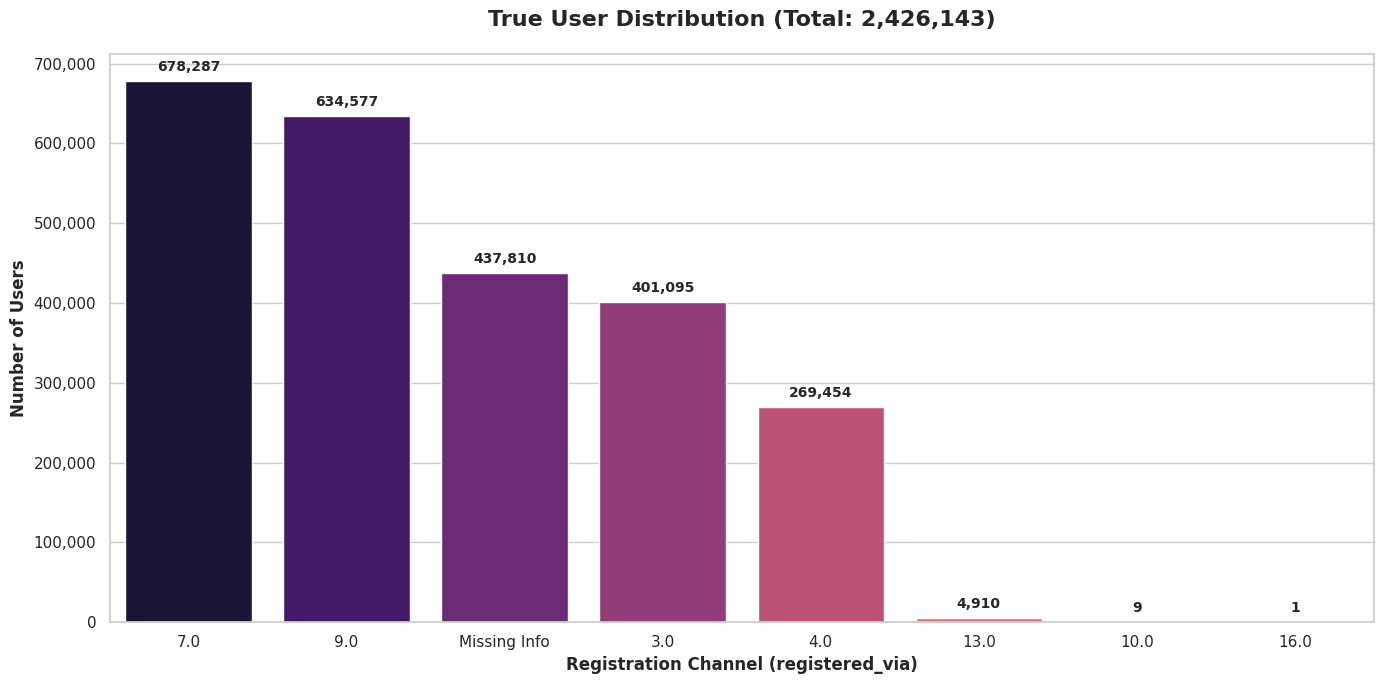

--- 🔍 DATA VERIFICATION TABLE ---


,registered_via,User_Count
2,7.0,678287
3,9.0,634577
7,Missing Info,437810
0,3.0,401095
1,4.0,269454
5,13.0,4910
4,10.0,9
6,16.0,1


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. LOAD DATA
target_path = 'raw_marketing_data/final_dashboard_data.parquet'
df_channels = pd.read_parquet(target_path, columns=['msno', 'registered_via'])

# 2. GROUPBY (Ensuring Nulls are NOT dropped)
channel_dist = df_channels.groupby('registered_via', dropna=False).agg(
    User_Count=('msno', 'count')
).reset_index()

# 3. FILLING NAN: Taaki graph mein 'Missing Info' ka bar dikhe
channel_dist['registered_via'] = channel_dist['registered_via'].fillna('Missing Info')

# 4. DATA SORTING & CALCULATIONS
channel_dist = channel_dist.sort_values(by='User_Count', ascending=False)
total_users_check = channel_dist['User_Count'].sum()

# 5. VISUALIZATION (The Final Graph)
plt.figure(figsize=(14, 7))
sns.set_theme(style="whitegrid")

# Modern palette use kar rahe hain
ax = sns.barplot(data=channel_dist, x='registered_via', y='User_Count', palette='magma')

# Bars ke upar exact labels (with comma formatting)
for p in ax.patches:
    ax.annotate(f'{int(p.get_height()):,}',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center',
                xytext=(0, 10),
                textcoords='offset points',
                fontsize=10, fontweight='bold')

# Chart Styling
plt.title(f'True User Distribution (Total: {total_users_check:,})', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Registration Channel (registered_via)', fontsize=12, fontweight='bold')
plt.ylabel('Number of Users', fontsize=12, fontweight='bold')

# Y-axis format update (100k notation)
current_values = plt.gca().get_yticks()
plt.gca().set_yticklabels(['{:,.0f}'.format(x) for x in current_values])

plt.tight_layout()
plt.show()

# Verification Table
print("--- 🔍 DATA VERIFICATION TABLE ---")
display(channel_dist)

In [ ]:
q = f"""
SELECT *
FROM '{trans_agg_path}'
limit 5
"""
result = duckdb.query(q).df()
result


,msno,total_transactions,sum_payment_plan_days,sum_plan_list_price,sum_actual_amount_paid,avg_payment_plan_days,avg_plan_list_price,avg_actual_amount_paid,first_transaction_date,last_transaction_date,latest_membership_expire_date,latest_payment_method_id,latest_is_auto_renew,latest_is_cancel,registered_via,registration_init_time,Tenure_Days,is_High_Value_User
0,zvdOYkuJw+l9dy6tAoWIfue3hFArtoP2b29rp6hmi+c=,27,810.0,4023.0,3963.0,30.000000,149.000000,146.777778,20150120,20170320,20170421,41,1,0,7.0,20120307.0,790,0
1,gV8BXr55HzHNe2/k4rYryZcKIJDf/Qy8nuwgiSPp6ts=,27,780.0,3874.0,4023.0,28.888889,143.481481,149.000000,20150125,20170325,20170426,41,1,0,7.0,20110524.0,790,1
2,qeKaMUxxI6mkREkv4TjfSlhuRguXcHLgCU85qdjuV6Y=,24,694.0,3685.0,3834.0,28.916667,153.541667,159.750000,20150103,20161226,20170125,36,0,0,9.0,20070618.0,723,1
3,pfJ0tXXzX/hw+8u/1UQw6MZ8m/iS/0HTu8I6aj93xdU=,27,783.0,4122.0,4271.0,29.000000,152.666667,158.185185,20150127,20170304,20170403,36,1,0,3.0,20130130.0,767,1
4,LjY17soH840CUVDpEUci4WgdD58E+ZiGbPz0uX75kns=,29,840.0,3972.0,4121.0,28.965517,136.965517,142.103448,20150113,20170331,20170430,41,1,0,7.0,20140714.0,808,1


# check outliers

In [ ]:
q = f"""
SELECT
    -- 1. Checking Negative Values (Kitne logo ka amount/days 0 se kam hai?)
    COUNTIF(sum_actual_amount_paid < 0) AS negative_paid_users,
    COUNTIF(sum_plan_list_price < 0) AS negative_price_users,
    COUNTIF(sum_payment_plan_days < 0) AS negative_days_users,

    -- 2. Checking Extreme High Values (Threshold aap apne hisaab se dekh sakte ho)
    -- Maan lete hain 50,000 se zyada payment ya 3650 (10 saal) se zyada days outlier hai
    COUNTIF(sum_actual_amount_paid > 50000) AS crazy_high_paid_users,
    COUNTIF(sum_payment_plan_days > 3650) AS crazy_high_days_users,

    -- 3. Just to see the extreme limits
    MIN(sum_actual_amount_paid) AS lowest_payment,
    MAX(sum_actual_amount_paid) AS highest_payment

FROM '{trans_agg_path}'
"""
result = duckdb.query(q).df()
result


,negative_paid_users,negative_price_users,negative_days_users,crazy_high_paid_users,crazy_high_days_users,lowest_payment,highest_payment
0,0.0,0.0,0.0,0.0,4.0,0.0,34299.0


# "What is the expected 'Active Life' of a user from each channel?"
